In [ ]:
import pandas as pd

In [ ]:
# Unzip the dataset
!unzip archive.zip -d mask_datasett

Streaming output truncated to the last 5000 lines.
  inflating: mask_datasett/data/with_mask/with_mask_3297.jpg  
  inflating: mask_datasett/data/with_mask/with_mask_3298.jpg  
  inflating: mask_datasett/data/with_mask/with_mask_3299.jpg  
  inflating: mask_datasett/data/with_mask/with_mask_33.jpg  
  inflating: mask_datasett/data/with_mask/with_mask_330.jpg  
  inflating: mask_datasett/data/with_mask/with_mask_3300.jpg  
  inflating: mask_datasett/data/with_mask/with_mask_3301.jpg  
  inflating: mask_datasett/data/with_mask/with_mask_3302.jpg  
  inflating: mask_datasett/data/with_mask/with_mask_3303.jpg  
  inflating: mask_datasett/data/with_mask/with_mask_3304.jpg  
  inflating: mask_datasett/data/with_mask/with_mask_3305.jpg  
  inflating: mask_datasett/data/with_mask/with_mask_3306.jpg  
  inflating: mask_datasett/data/with_mask/with_mask_3307.jpg  
  inflating: mask_datasett/data/with_mask/with_mask_3308.jpg  
  inflating: mask_datasett/data/with_mask/with_mask_3309.jpg  
  infla

In [ ]:
import os
import matplotlib.pyplot as plt
import cv2
import matplotlib.image as mpimg
from google.colab.patches import cv2_imshow
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [ ]:
with_facemask = os.listdir('/content/mask_datasett/data/with_mask')
print("number of images with facemask:",len(with_facemask))

number of images with facemask: 3725


In [ ]:
without_facemask = os.listdir('/content/mask_datasett/data/without_mask')
print("number of images without facemask:",len(without_facemask))

number of images without facemask: 3828


In [ ]:
# we store mask and without mask data in a list with varialbe name.

In [ ]:
print(with_facemask[:5])

['with_mask_3040.jpg', 'with_mask_2212.jpg', 'with_mask_3383.jpg', 'with_mask_2316.jpg', 'with_mask_2610.jpg']


In [ ]:
print(without_facemask[:5])

['without_mask_1139.jpg', 'without_mask_2309.jpg', 'without_mask_224.jpg', 'without_mask_2231.jpg', 'without_mask_3069.jpg']


In [ ]:
# create label

# without mask = 0

# withmask = 1

In [ ]:
with_facemask_label= [1]*3725
without_facemask_label= [0]*3828

In [ ]:
labels = with_facemask_label + without_facemask_label

In [ ]:
print(labels)

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 

In [ ]:
print(len(labels))

7553


In [ ]:
#display the images

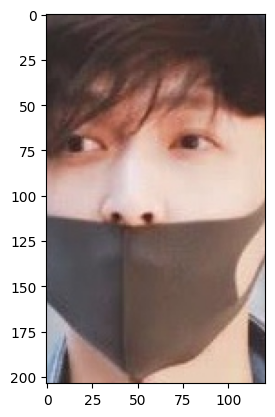

In [ ]:
img = mpimg.imread('/content/mask_datasett/data/with_mask/with_mask_1001.jpg')
imgplot = plt.imshow(img)
plt.show()

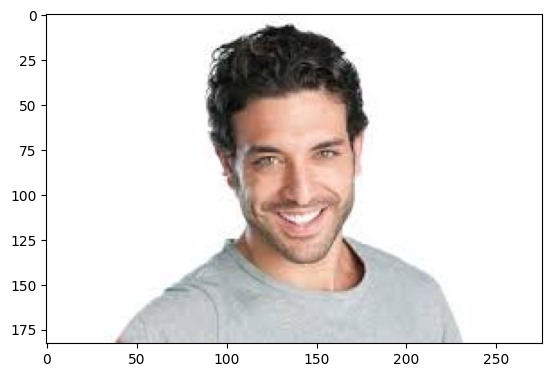

In [ ]:
img = mpimg.imread('/content/mask_datasett/data/without_mask/without_mask_1000.jpg')
imgplot = plt.imshow(img)
plt.show()

In [ ]:
# images preprocessing
# 1 resize the image
# 2 convet to np array.
import numpy as np

In [ ]:
with_mask_path = "/content/mask_datasett/data/with_mask"
without_mask_path = "/content/mask_datasett/data/without_mask"

with_facemask = os.listdir(with_mask_path)
without_facemask = os.listdir(without_mask_path)

In [ ]:


data=[]
labelss=[]

for img_file in with_facemask:
    img_path = os.path.join(with_mask_path, img_file)

    image = cv2.imread(img_path)                  # load image
    image = cv2.resize(image, (128, 128))         # resize
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # convert BGR → RGB

    data.append(image)
    labelss.append(1)   # mask = 1

# -----------------------------
# Load WITHOUT MASK using OpenCV
# -----------------------------
for img_file in without_facemask:
    img_path = os.path.join(without_mask_path, img_file)

    image = cv2.imread(img_path)
    image = cv2.resize(image, (128, 128))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    data.append(image)
    labelss.append(0)   # no mask = 0

In [ ]:
type(data)

list

In [ ]:
len(data)

7553

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[ 30,  30,  30],
        [ 30,  30,  30],
        [ 30,  30,  30],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[ 30,  30,  30],
        [ 30,  30,  30],
        [ 30,  30,  30],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[ 30,  30,  30],
        [ 31,  31,  31],
        [ 31,  31,  31],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
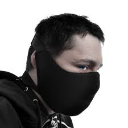

In [ ]:
data[0]

In [ ]:
type(data[0])

numpy.ndarray

In [ ]:
# now convert label into numpy array bxz they are in list [1111100000]

In [ ]:
x=np.array(data)
y=np.array(labelss)

In [ ]:
type(x)

numpy.ndarray

In [ ]:
type(y)

numpy.ndarray

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[ 30,  30,  30],
        [ 30,  30,  30],
        [ 30,  30,  30],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[ 30,  30,  30],
        [ 30,  30,  30],
        [ 30,  30,  30],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[ 30,  30,  30],
        [ 31,  31,  31],
        [ 31,  31,  31],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
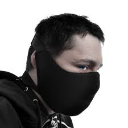

In [ ]:
x[0]

In [ ]:
y[0]

np.int64(1)

In [ ]:
print(x.shape)

(7553, 128, 128, 3)


In [ ]:
print(y.shape)

(7553,)


In [ ]:
# train test split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [ ]:
print(x.shape,x_train.shape,x_test.shape)

(7553, 128, 128, 3) (6042, 128, 128, 3) (1511, 128, 128, 3)


In [ ]:
# scaling the data
x_train_scaled = x_train / 255
x_test_scaled = x_test / 255

In [ ]:
# build the model cnn
import tensorflow as tf
from tensorflow import keras
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout


In [ ]:
num_of_classes = 2

model = keras.Sequential()

model.add(keras.layers.Conv2D(32,kernel_size=(3,3),activation='relu',input_shape=(128,128,3)))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(keras.layers.Conv2D(64,kernel_size=(3,3),activation='relu'))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(keras.layers.Flatten())

model.add(keras.layers.Dense(128,activation='relu'))
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(64,activation='relu'))
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(num_of_classes,activation='sigmoid'))



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# compile the neural network
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['acc'])

In [ ]:
# traininf the model

history = model.fit(x_train_scaled,y_train,validation_split=0.1,epochs=5)

Epoch 1/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 14s 47ms/step - acc: 0.7081 - loss: 0.6375 - val_acc: 0.8942 - val_loss: 0.2904
Epoch 2/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - acc: 0.8712 - loss: 0.3091 - val_acc: 0.8727 - val_loss: 0.2764
Epoch 3/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - acc: 0.8984 - loss: 0.2490 - val_acc: 0.8975 - val_loss: 0.2423
Epoch 4/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - acc: 0.9092 - loss: 0.2096 - val_acc: 0.9207 - val_loss: 0.1966
Epoch 5/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - acc: 0.9250 - loss: 0.2076 - val_acc: 0.9025 - val_loss: 0.2288


In [ ]:
# MODEL EVALUATION
loss,accuracy=model.evaluate(x_test_scaled,y_test)
print("test accuracy:",accuracy)

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - acc: 0.9126 - loss: 0.2052
test accuracy: 0.9146260619163513


In [ ]:
loss,accuracy=model.evaluate(x_train_scaled,y_train)
print("train accuracy:",accuracy)

189/189 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - acc: 0.9463 - loss: 0.1186
train accuracy: 0.9394240379333496


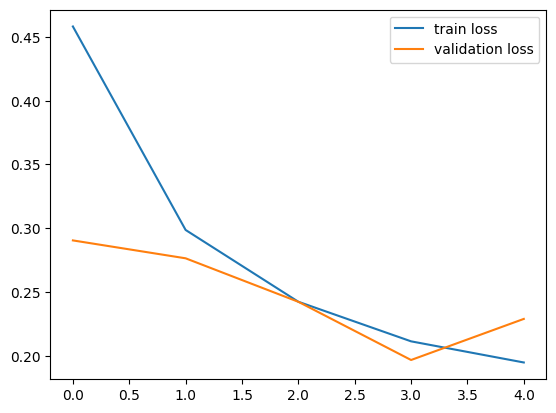

In [ ]:
h = history

plt.plot(h.history['loss'],label='train loss')
plt.plot(h.history['val_loss'],label='validation loss')
plt.legend()
plt.show()

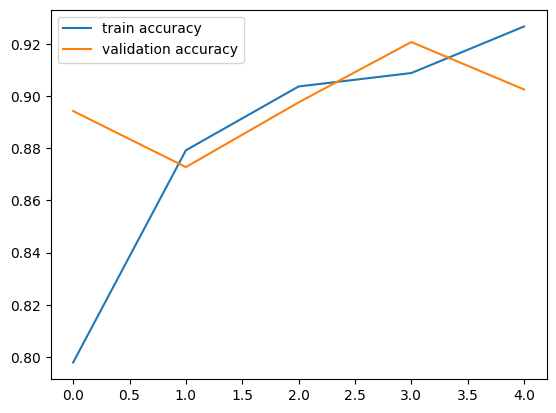

In [ ]:
plt.plot(h.history['acc'],label='train accuracy')
plt.plot(h.history['val_acc'],label='validation accuracy')
plt.legend()
plt.show()

enter the image path:/content/mask_datasett/data/with_mask/with_mask_100.jpg


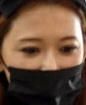

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 632ms/step
THE PERSON IN THE IMAGE IS WEARING A MASK..


In [ ]:
# build predictive system
import numpy as np
from keras.preprocessing import image


user_input_img = input("enter the image path:")
read_image = cv2.imread(user_input_img)

cv2_imshow(read_image)

user_img_resize = cv2.resize(read_image,(128,128))

user_img_rescaled = user_img_resize/255

user_img_reshaped = np.reshape(user_img_rescaled,[1,128,128,3])

result = model.predict(user_img_reshaped)
#print(result)

result_label = np.argmax(result)

#print(result_label)

if result_label == 1:
  print("THE PERSON IN THE IMAGE IS WEARING A MASK..")

else:
  print("THE PEROSN IN THE IMAGE IS NOT WERAING A MASK..")



In [ ]:
# Save the model
model.save("model.h5")

# Load the model back
from tensorflow.keras.models import load_model
loaded_model = load_model("model.h5")

# Now you can use loaded_model.predict(...)
